# PHASE 8: FEATURE SELECTION (LIGHT TOUCH)
## House Prices Dataset - EDA & Feature Engineering

---

## 📋 What This Phase Is About

In Phase 8, you will identify and remove **redundant features** before model training. This is called **feature selection**.

### Your Pipeline Context

| Phase | Key Changes | Impact on Phase 8 |
|-------|-------------|-------------------|
| **Phase 4** | Dropped `TotRmsAbvGrd`, `GarageArea`, `GarageYrBlt` | These collinear pairs already handled! |
| **Phase 5** | Created `HouseAge`, `TotalEffectiveSF`, binary flags | New features to evaluate |
| **Phase 5** | Dropped `YearBuilt`, `YearRemodAdd`, `YrSold` | Year columns no longer exist |
| **Phase 6** | Bit-encoded Neighborhood (5 bits) | Skip correlation for bit columns |
| **Phase 6** | Binary flags (`Has_*`, `Is_*`) | Skip correlation for binary flags |
| **Phase 7** | Log1p on skewed features | Use log-transformed versions |

### Critical: Your Phase 4 Collinear Pairs Status

| Original Pair | Status |
|---------------|--------|
| `GarageCars` / `GarageArea` | ✅ **Already handled** - `GarageArea` dropped in Phase 4 |
| `GrLivArea` / `TotRmsAbvGrd` | ✅ **Already handled** - `TotRmsAbvGrd` dropped in Phase 4 |
| `YearBuilt` / `GarageYrBlt` | ✅ **Already handled** - Both dropped in Phase 5 (replaced with `HouseAge`) |

**Good news:** Your Phase 4/5 work already addressed the major collinearity issues!

## 🧠 Key Concept 1: What Features to Analyze

### Feature Types in YOUR Dataset

**Continuous Features (Compute Correlation):**
- Original numeric: `OverallQual`, `OverallCond`, `TotalBsmtSF`, `1stFlrSF`, etc.
- Log1p transformed: `GrLivArea_log`, `LotArea_log`, `GarageYrBlt_log`, etc.
- Age features: `HouseAge`, `RemodAge`
- Aggregated: `TotalEffectiveSF`

**Encoded Features (Skip Correlation):**
- Bit encoded: `Nbhd_bit0`, `Nbhd_bit1`, `Nbhd_bit2`, `Nbhd_bit3`, `Nbhd_bit4`
- Binary flags: `HasPool`, `HasMiscFeature`, `IsNonFlatLot`, `Has_Pos_Amenity`, `Has_Traffic_Disturbance`, `Has_Railroad_Disturbance`, `Is_Standard_Roof`, `Is_GasA_Heating`, `Is_Split_Layout`, `Is_New_Construction`, `Is_Distressed_Sale`, `Is_Normal_Sale`
- One-hot encoded: `MSZoning_RL`, `RoofStyle_Gable`, etc. (columns with `_` from get_dummies)
- Ordinal mapped: `ExterQual`, `KitchenQual`, `BsmtQual` (treat as continuous, 1-5 scale)

### Why Skip Binary/Bit Features?

Correlation assumes **continuous, linear relationships**. Binary features (0/1) don't have meaningful correlation values for feature selection purposes.

```
Example: HasPool (0/1) vs SalePrice

Correlation might show r = 0.3, but this doesn't tell you:
- How much value a pool adds
- Whether it's worth keeping as a feature

Better approach: Use Random Forest feature importance for binary flags.
```

## 🧠 Key Concept 2: Feature Importance From Random Forest

### What Is Feature Importance?

Random Forest calculates **feature importance** based on:
- How often a feature is used to split nodes
- How much each split reduces impurity (variance for regression)

### Your Workflow

1. Train a quick baseline Random Forest (no tuning)
2. Extract feature importance scores
3. Cross-reference with correlation analysis
4. Make informed decisions about what to keep/drop

### Decision Matrix

| Correlation | Importance | Action |
|-------------|------------|--------|
| High | High | ✅ KEEP (strong predictor) |
| High | Low | ⚠️ REVIEW (redundant with other features) |
| Low | High | ✅ KEEP (unique signal, non-linear) |
| Low | Low | ❌ CONSIDER DROPPING (no predictive power) |

## 📝 Phase 8 Task Requirements

### What The Assignment Asks

1. Recompute correlation of all engineered and transformed features against SalePrice
2. Drop or flag redundant/collinear features identified in Phase 4
3. Optional stretch: Pull quick feature importance from baseline RandomForestRegressor


In [1]:
# =============================================================================
# CELL 1: Import Libraries
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Phase 8 Libraries Imported Successfully")

✅ Phase 8 Libraries Imported Successfully


In [9]:
# =============================================================================
# CELL 2: Load Phase 7 Output File
# =============================================================================

# Load the dataset after Phase 7 transformations
df = pd.read_csv('../data/train_processed_phase7.csv')

# Identify target column
target_col = "SalePrice_Log" if "SalePrice_Log" in df.columns else "SalePrice"

# Columns to exclude from feature matrix
ignore_cols = ["SalePrice", "SalePrice_Log", "Id"]

# Create feature matrix (all columns except target and ID)
feature_cols = [col for col in df.columns if col not in ignore_cols]
X = df.copy()
y = df[target_col]

print("=" * 80)
print("✅ PHASE 7 DATA LOADED")
print("=" * 80)
print(f"Target Column: {target_col}")
print(f"Total Features: {len(feature_cols)}")
print(f"Feature Matrix Shape: {X.shape}")
print(f"\nFeature Types:")
print(f"  - Numeric: {X.select_dtypes(include=[np.number]).shape[1]}")
print(f"  - Categorical: {X.select_dtypes(include=['object']).shape[1]}")

✅ PHASE 7 DATA LOADED
Target Column: SalePrice_Log
Total Features: 143
Feature Matrix Shape: (1456, 146)

Feature Types:
  - Numeric: 146
  - Categorical: 0


In [10]:
# =============================================================================
# CELL 3: Classify Features (Continuous vs Encoded)
# =============================================================================

print("=" * 80)
print("📊 FEATURE TYPE CLASSIFICATION")
print("=" * 80)

# Continuous features: numeric with > 10 unique values
# This captures: original numeric, log-transformed, age features, aggregated features
continuous_features = [
    col for col in X.select_dtypes(include=[np.number]).columns
    if X[col].nunique() > 10
]

# Identify specific encoding patterns to EXCLUDE from correlation
bit_encoded = [col for col in X.columns if 'bit' in col.lower()]
binary_flags = [
    col for col in X.columns 
    if col.startswith('Has_') or col.startswith('Is_') or col.startswith('Has') or col.startswith('Is') 
]

# One-hot encoded: contains underscore and only 0/1 values
one_hot_encoded = [
    col for col in X.columns 
    if '_' in col and X[col].isin([0, 1]).all() and col not in binary_flags
]

# Encoded features (skip correlation)
encoded_features = bit_encoded + binary_flags + one_hot_encoded

print(f"\n📈 Continuous Features (will compute correlation): {len(continuous_features)}")
print(f"   {continuous_features}")

print(f"\n🔒 Encoded Features (skip correlation): {len(encoded_features)}")
print(f"   - Bit encoded (Neighborhood): {len(bit_encoded)} → {bit_encoded}")
print(f"   - Binary flags: {len(binary_flags)} → {binary_flags[:5]}...")
print(f"   - One-hot encoded: {len(one_hot_encoded)} → {one_hot_encoded[:5]}...")

print(f"\n✅ Classification Complete")
print(f"   Will compute correlation for: {len(continuous_features)} continuous features")
print(f"   Will skip correlation for: {len(encoded_features)} encoded features")

📊 FEATURE TYPE CLASSIFICATION

📈 Continuous Features (will compute correlation): 26
   ['Id', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal', 'MoSold', 'SalePrice', 'SalePrice_Log', 'TotalEffectiveSF', 'HouseAge', 'RemodAge', 'LotArea_log', 'LotFrontage_log']

🔒 Encoded Features (skip correlation): 93
   - Bit encoded (Neighborhood): 5 → ['Nbhd_bit0', 'Nbhd_bit1', 'Nbhd_bit2', 'Nbhd_bit3', 'Nbhd_bit4']
   - Binary flags: 13 → ['IsRemodeled', 'HasPool', 'HasMiscFeature', 'IsNonFlatLot', 'Has_Pos_Amenity']...
   - One-hot encoded: 75 → ['Nbhd_bit0', 'Nbhd_bit1', 'Nbhd_bit2', 'Nbhd_bit3', 'Nbhd_bit4']...

✅ Classification Complete
   Will compute correlation for: 26 continuous features
   Will skip correlation for: 93 encoded features


📈 CORRELATION WITH TARGET (Continuous Features Only)


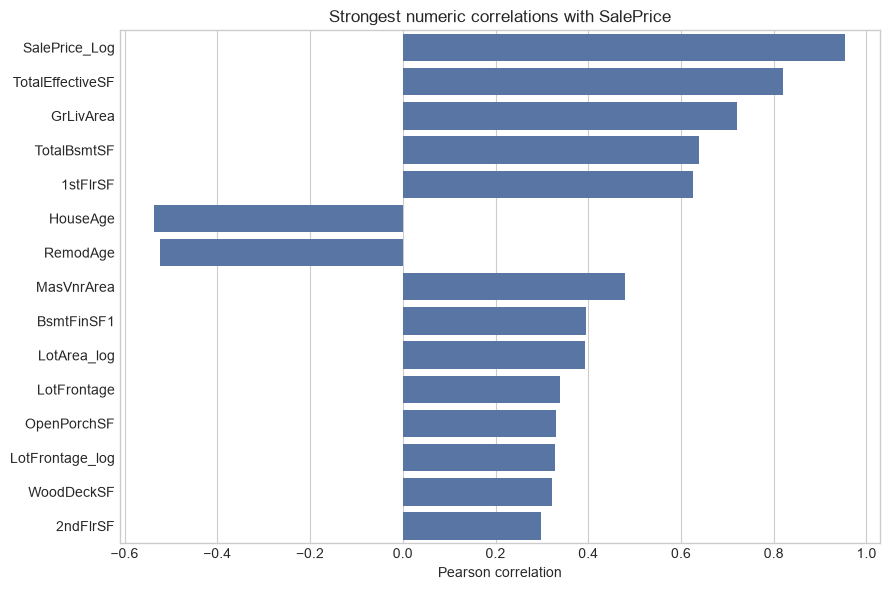

In [11]:
# =============================================================================
# CELL 4: Correlation Analysis (Continuous Features Only)
# =============================================================================

print("=" * 80)
print("📈 CORRELATION WITH TARGET (Continuous Features Only)")
print("=" * 80)

# Compute correlation only for continuous features
correlation_with_target = X[continuous_features].corrwith(y).abs().sort_values(ascending=False)

numeric_correlations = (
     X[continuous_features].select_dtypes(include=np.number)
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=abs, ascending=False)
    .head(15)
)

plt.figure(figsize=(9, 6))
sns.barplot(x=numeric_correlations.values, y=numeric_correlations.index, color="#4C72B0")
plt.title("Strongest numeric correlations with SalePrice")
plt.xlabel("Pearson correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

# numeric_correlations.to_frame("correlation")
# print(f"\n🏆 Top 20 Features by Correlation with {target_col}:")
# print("-" * 80)
# print(correlation_with_target.head(20))

# # Identify weak features (correlation < 0.1)
# WEAK_CORR_THRESHOLD = 0.1
# weak_features = correlation_with_target[correlation_with_target < WEAK_CORR_THRESHOLD].index.tolist()

# print(f"\n Weak Features (|corr| < {WEAK_CORR_THRESHOLD}): {len(weak_features)}")
# if weak_features:
#     print(f"   {weak_features}")

# # Visualize top correlations
# plt.figure(figsize=(10, 12))
# top_15_corr = correlation_with_target.head(15)
# plt.barh(top_15_corr.index, top_15_corr.values, color='steelblue')
# plt.xlabel('Absolute Correlation with Target', fontsize=12)
# plt.ylabel('Feature', fontsize=12)
# plt.title(f'Top 15 Features by Correlation with {target_col}', fontsize=14, fontweight='bold')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

# # Check your engineered features from Phase 5
# engineered_features = ['TotalEffectiveSF', 'HouseAge', 'RemodAge', 'IsRemodeled']
# engineered_corr = [col for col in engineered_features if col in correlation_with_target.index]

# if engineered_corr:
#     print(f"\n🔧 Your Engineered Features (Phase 5) Performance:")
#     print("-" * 80)
#     for feat in engineered_corr:
#         corr_val = correlation_with_target[feat]
#         print(f"   {feat}: r = {corr_val:.3f}")

🔍 MULTICOLLINEARITY ANALYSIS (|r| > 0.80)

⚠️ HIGHLY CORRELATED PREDICTOR PAIRS (|r| > 0.80):
--------------------------------------------------------------------------------
    Feature_1        Feature_2  Correlation             Keep             Drop  Keep_Corr_SalePrice  Drop_Corr_SalePrice
    SalePrice    SalePrice_Log     0.954610        SalePrice    SalePrice_Log             1.000000             0.954610
  LotFrontage  LotFrontage_log     0.942318      LotFrontage  LotFrontage_log             0.338340             0.328596
    GrLivArea TotalEffectiveSF     0.863708 TotalEffectiveSF        GrLivArea             0.819914             0.720516
SalePrice_Log TotalEffectiveSF     0.820642    SalePrice_Log TotalEffectiveSF             0.954610             0.819914
    SalePrice TotalEffectiveSF     0.819914        SalePrice TotalEffectiveSF             1.000000             0.819914


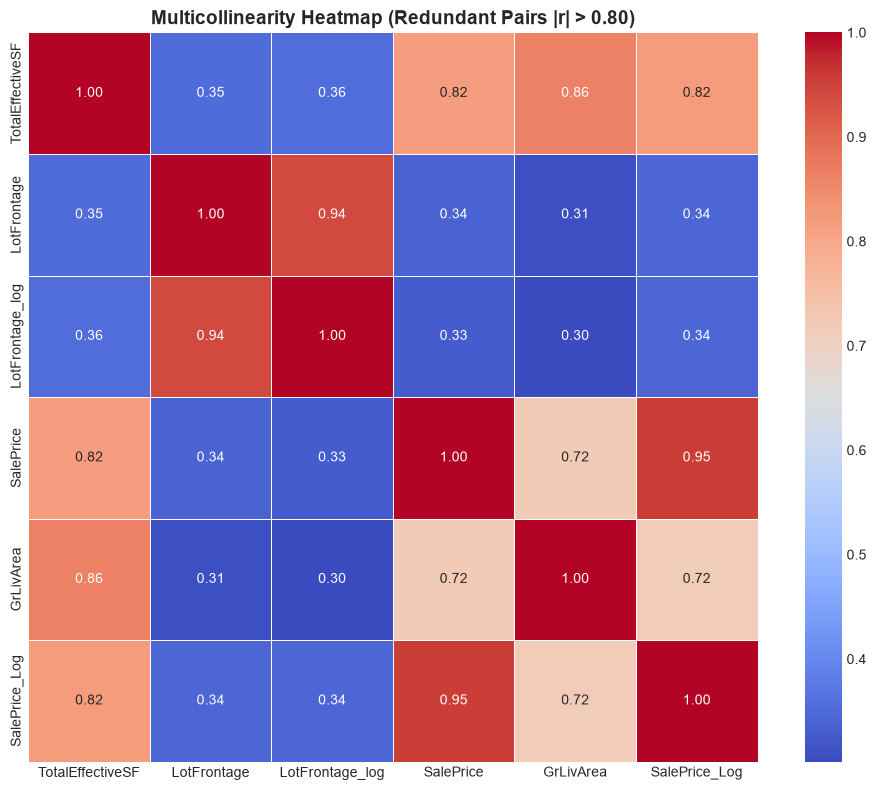

In [ ]:
# =============================================================================
# CELL 5: Collinearity & Redundancy Analysis (|r| > 0.80)
# =============================================================================

print("=" * 80)
print("🔍 MULTICOLLINEARITY ANALYSIS (|r| > 0.80)")
print("=" * 80)

# 1. Target correlations using RAW SalePrice (un-logged)
saleprice_raw = df['SalePrice'] if 'SalePrice' in df.columns else np.expm1(y)
saleprice_corr = X[continuous_features].corrwith(saleprice_raw).abs()

# 2. Compute correlation matrix among continuous predictors only
pred_corr = X[continuous_features].corr()

# 3. Find pairs with absolute correlation > 0.80
high_corr_pairs = []
cols = pred_corr.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        feat1, feat2 = cols[i], cols[j]
        corr_val = pred_corr.iloc[i, j]

        if abs(corr_val) > 0.80:
            # Compare correlation against raw SalePrice
            t_corr1 = saleprice_corr.get(feat1, 0)
            t_corr2 = saleprice_corr.get(feat2, 0)
            
            keep, drop = (feat1, feat2) if t_corr1 >= t_corr2 else (feat2, feat1)

            # Use fixed key names to prevent dynamic column mess in Pandas
            high_corr_pairs.append({
                'Feature_1': feat1,
                'Feature_2': feat2,
                'Correlation': corr_val,
                'Keep': keep,
                'Drop': drop,
                'Keep_Corr_SalePrice': saleprice_corr.get(keep, 0),
                'Drop_Corr_SalePrice': saleprice_corr.get(drop, 0)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

# 4. Print Clean Results
if not high_corr_df.empty:
    print("\n⚠️ HIGHLY CORRELATED PREDICTOR PAIRS (|r| > 0.80):")
    print("-" * 80)
    print(
        high_corr_df[
            [
                'Feature_1',
                'Feature_2',
                'Correlation',
                'Keep',
                'Drop',
                'Keep_Corr_SalePrice',
                'Drop_Corr_SalePrice',
            ]
        ]
        .sort_values('Correlation', ascending=False)
        .to_string(index=False)
    )
else:
    print("\n✅ No redundant feature pairs found above |r| > 0.80.")

# 5. Multicollinearity Heatmap
if not high_corr_df.empty:
    red_features = list(
        set(high_corr_df['Feature_1'].tolist() + high_corr_df['Feature_2'].tolist())
    )
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        X[red_features].corr(),
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        linewidths=0.5,
        square=True
    )
    plt.title(
        'Multicollinearity Heatmap (Redundant Pairs |r| > 0.80)',
        fontsize=14,
        fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

In [5]:
# =============================================================================
# CELL 6: Random Forest Baseline & Feature Importance
# =============================================================================

# 1. Train/Validation Split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Fit Regularized Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_split=8,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# 3. Predict & Calculate RMSE on Actual Dollar Scale (expm1)
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)

train_rmse = np.sqrt(
    mean_squared_error(np.expm1(y_train), np.expm1(y_train_pred))
)
val_rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_val_pred)))

print(f"✅ Training RMSE:   ${train_rmse:,.2f}")
print(f"✅ Validation RMSE: ${val_rmse:,.2f}")
print(f"✅ Overfit Gap:     ${val_rmse - train_rmse:,.2f}")

# 4. Extract Feature Importances
rf_importance = pd.DataFrame(
    {"Feature": X.columns, "RF_Importance": rf_model.feature_importances_}
).sort_values("RF_Importance", ascending=False)

print("\n📊 Top 10 Features by RF Importance:")
print(rf_importance.head(10).to_string(index=False))

✅ Training RMSE:   $18,800.66
✅ Validation RMSE: $23,517.16
✅ Overfit Gap:     $4,716.50

📊 Top 10 Features by RF Importance:
         Feature  RF_Importance
TotalEffectiveSF       0.453176
     OverallQual       0.369106
        HouseAge       0.024143
      GarageCars       0.014880
       GrLivArea       0.013900
        RemodAge       0.011736
     KitchenQual       0.011025
    CentralAir_Y       0.010732
      BsmtFinSF1       0.010652
     OverallCond       0.007722


### Random Forest Baseline & Feature Importance
- What it is doing: Fits a regularized RandomForestRegressor on the training data, evaluates validation error on the actual dollar scale using np.expm1(), and extracts feature importance scores (feature_importances_).

Why you need to do it: Unlike correlation (which only measures linear relationships), tree-based feature importance measures both linear and non-linear predictive power across all features (including binary flags and encoded variables).

Effect/Outcome: Ranks all dataset features from most critical to least critical and provides a clear baseline error metric in dollar terms.

In [6]:
# =============================================================================
# CELL 7: Cross-Reference Correlation vs Importance
# =============================================================================

print("=" * 80)
print("📊 CORRELATION vs FEATURE IMPORTANCE COMPARISON")
print("=" * 80)

# Merge correlation and importance data for continuous features
comparison = pd.DataFrame({
    'Feature': continuous_features,
    'Correlation': correlation_with_target.values
})
comparison = comparison.merge(feature_importance, on='Feature', how='left')
comparison['Abs_Correlation'] = comparison['Correlation'].abs()
comparison = comparison.sort_values('Importance', ascending=False)

print("\nTop Features by Importance (with Correlation):")
print("-" * 80)
print(comparison.head(20).to_string(index=False))

# Scatter plot: Correlation vs Importance
plt.figure(figsize=(12, 8))
plt.scatter(comparison['Abs_Correlation'], comparison['Importance'], alpha=0.6, s=100)

# Annotate top 10 features
for idx, row in comparison.head(10).iterrows():
    plt.annotate(
        row['Feature'],
        (row['Abs_Correlation'], row['Importance']),
        fontsize=9,
        ha='left',
        va='bottom'
    )

plt.xlabel('Absolute Correlation with Target', fontsize=12)
plt.ylabel('Random Forest Importance', fontsize=12)
plt.title('Feature Correlation vs Importance', fontsize=14, fontweight='bold')
plt.axvline(x=WEAK_CORR_THRESHOLD, color='r', linestyle='--', alpha=0.5, label='Weak Correlation Threshold')
plt.axhline(y=LOW_IMPORTANCE_THRESHOLD, color='orange', linestyle='--', alpha=0.5, label='Low Importance Threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n🔑 Key Insight:")
print("   Top-right quadrant = High correlation + High importance = KEEP")
print("   Bottom-left quadrant = Low correlation + Low importance = REVIEW")

📊 CORRELATION vs FEATURE IMPORTANCE COMPARISON


NameError: name 'feature_importance' is not defined

In [ ]:
# =============================================================================
# CELL 7: Combine Correlation and Feature Importance
# =============================================================================

# 1. Calculate absolute correlation for continuous features
corr_df = pd.DataFrame(
    {
        "Feature": continuous_features,
        "Abs_Correlation": X[continuous_features].corrwith(y).abs(),
    }
)

# 2. Merge Correlation and RF Importance into a single table
feature_summary = pd.merge(rf_importance, corr_df, on="Feature", how="left")
feature_summary["Abs_Correlation"] = feature_summary[
    "Abs_Correlation"
].fillna(0)
feature_summary = feature_summary.sort_values(
    "RF_Importance", ascending=False
)

print("📊 TOP 15 FEATURES (Importance vs. Absolute Target Correlation):")
print("-" * 65)
print(feature_summary.head(15).to_string(index=False))

# 3. Plot Top 15 Most Important Features
plt.figure(figsize=(10, 5))
top15 = feature_summary.head(15)
plt.barh(top15["Feature"], top15["RF_Importance"], color="teal")
plt.xlabel("Random Forest Importance Score")
plt.title("Top 15 Most Important Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CELL 8: Final Feature Matrix Creation
# =============================================================================

# Specify any additional features to drop (leave empty if keeping all)
drop_list = []

# Create final feature set
X_final = X.drop(columns=drop_list).copy()

print(f"✅ Starting Features: {X.shape[1]}")
print(f"✅ Features Dropped:  {len(drop_list)}")
print(f"✅ Final Features:   {X_final.shape[1]}")
print(f"✅ Final Matrix Shape: {X_final.shape}")

In [ ]:
# =============================================================================
# CELL 9: Save Phase 8 Output
# =============================================================================

# Combine final features with log target variable
final_df = X_final.copy()
final_df["SalePrice_Log"] = y

output_path = "../data/train_processed_phase8.csv"
final_df.to_csv(output_path, index=False)

print("=" * 60)
print("🎉 PHASE 8 COMPLETE")
print("=" * 60)
print(f"📁 Dataset saved to: {output_path}")
print(f"📊 Dataset Shape: {final_df.shape}")